# 📈Pythonで株分析遊び

## 目標
- 買いたい株の買い時を予測したい
    - そもそも株は，投機よりもその会社を応援する意味で持っておきたい（といっても，IPOや新規株式発行の時に買わないと意味ない？; いや，株価の下支えはできるお）
    - でも，どうせ株を買うなら安く買いたい
- 市場が判断している株価が，その会社が持っている価値よりも低いときが買い時？
- たまにTechTeacherで株予測モデルの求人がある気がする．そういう求人にも役立ちそう．
- あくまでも遊びね！だって株を安く買うこと自体は市場に価値を生んでいないから．大事なのは株という仕組みを使って社会に実益をもたらすこと．これに誠心誠意をかけることがないように心に誓わねば

## 対象
### 方針
- 世界で競争力を持つ日本企業
    - 素材
    - 医療
    - 光学
    - 農耕機
### 銘柄
- 3402.T Toray
- 4543.T Terumo
- 4901.T Fujifilm (持ってる)
- 4902.T Konica Minolta: 社名が可愛い; Minolta Rokkor, もうカメラつくってないけど...
- 6301.T Komatsu
- 6326.T Kubota
- 6741.T Nippon Signal: 改札の未来がんばってほしい
- 6758.T Sony Group (持ってる): Imaging圧倒的, α
- 6857.T Advantest: 社名が可愛い, けど割高すぎ
- 6952.T CASIO計算機: CASIO製品の丈夫さとデザイン性が好き
- 7012.T Kawasaki: Ninja欲しい😍
- 7270.T Subaru: アウトドアSUVのラインが良い!
- 7272.T ヤマハ発動機: ヤマハバイクのデザイン好き; [株主還元](https://global.yamaha-motor.com/jp/ir/individual/club/)手厚い
- 7309.T シマノ
- 7713.T Sigma光機
- 7741.T HOYA
- 7751.T キヤノン
- 7944.T Roland
- 7951.T ヤマハ (持ってる): ベースもギターもピアノも美しく良くデザインされていて好き

In [16]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

[*********************100%***********************]  3 of 3 completed


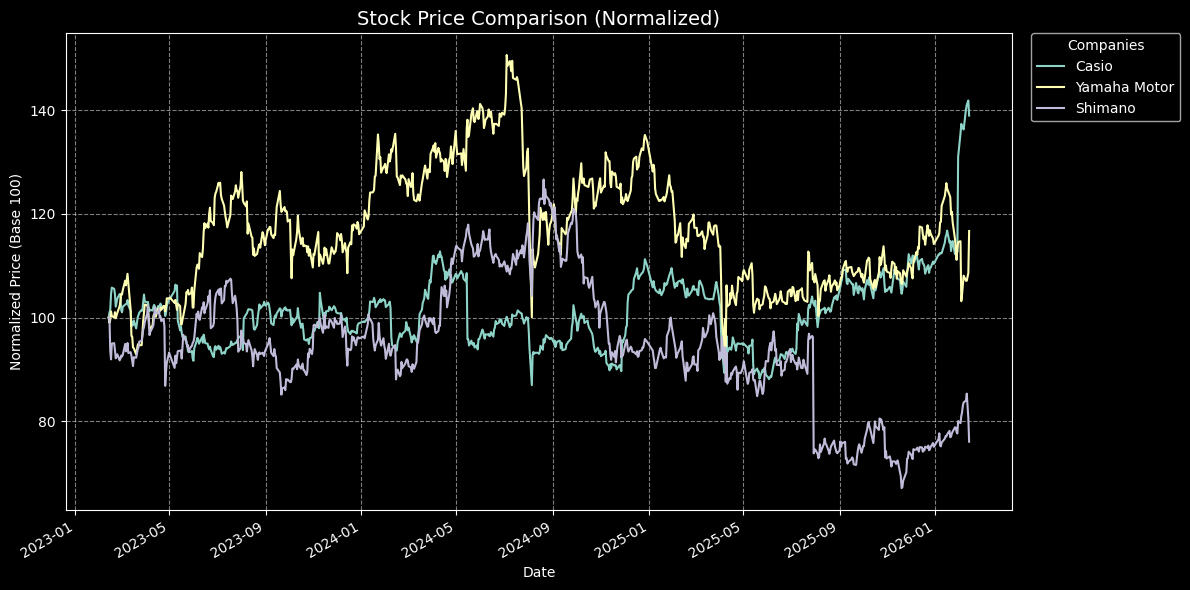

In [10]:
stocks = {
    # "3402.T": "Toray",
    # "4543.T": "Terumo",
    # "4901.T": "Fujifilm",
    # "4902.T": "Konica Minolta",
    # "6301.T": "小松製作所",
    # "6326.T": "クボタ",
    # "6741.T": "日本信号",
    # "6758.T": "ソニーグループ",
    # "6857.T": "アドバンテスト",
    "6952.T": "Casio",
    # "7012.T": "Kawasaki",
    # "7270.T": "SUBARU",
    "7272.T": "Yamaha Motor",
    "7309.T": "Shimano",
    # "7713.T": "シグマ光機",
    # "7741.T": "HOYA",
    # "7751.T": "キヤノン",
    # "7944.T": "ローランド",
    # "7951.T": "ヤマハ"
}

tickers = list(stocks.keys())

data = yf.download(tickers, period="3y")['Close']

normalized_data = (data / data.iloc[0]) * 100

fig_height = max(6, len(tickers) * 0.4)
ax = normalized_data.plot(figsize=(12, fig_height))

plt.title("Stock Price Comparison (Normalized)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Normalized Price (Base 100)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)

labels = [stocks[t] for t in data.columns]
plt.legend(labels, title="Companies", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

In [22]:
print("投資判断指標")

for ticker in tickers:
    info = yf.Ticker(ticker).info

    name = stocks.get(ticker, "Unknown")
    per = info.get("forwardPE")
    pbr = info.get("priceToBook")
    div = info.get("dividendYield")
    roe = info.get("returnOnEquity")
    debt = info.get("debtToEquity")
    m_cap = info.get("marketCap")

    per_str = f"{per:.2f}" if per else "N/A"
    pbr_str = f"{pbr:.2f}" if pbr else "N/A"
    div_str = f"{div * 100:.2f}%" if div else "0.00%"
    roe_str = f"{roe * 100:.2f}%" if roe else "N/A"
    m_cap_str = f"{int(m_cap / 100_000_000):,}億円" if m_cap else "N/A"

    print(f"[{ticker}] {name}")
    print(f"  PER(予): {per_str} / PBR: {pbr_str} / 配当利回り: {div_str} / ROE: {roe_str} / 時価総額: {m_cap_str}")

    if pbr and pbr < 1.0:
        print("  * PBR<1.0")
    if div and div >= 0.03:
        print("  * 3%<div")

投資判断指標
[6952.T] Casio
  PER(予): 30.30 / PBR: 1.58 / 配当利回り: 276.00% / ROE: 8.48% / 時価総額: 3,647億円
  * 3%<div
[7272.T] Yamaha Motor
  PER(予): 6.26 / PBR: 1.04 / 配当利回り: 317.00% / ROE: 2.33% / 時価総額: 11,489億円
  * 3%<div
[7309.T] Shimano
  PER(予): 18.20 / PBR: 1.67 / 配当利回り: 204.00% / ROE: 3.90% / 時価総額: 14,487億円
  * 3%<div


In [30]:
import yfinance as yf

ticker = yf.Ticker("7272.T")

# 1. 財務諸表の取得 (過去4年分)
income_stmt = ticker.financials       # 損益計算書
balance_sheet = ticker.balance_sheet # 貸借対照表

# 2. 必要なデータの抽出
# ROE = 当期純利益 / 自己資本
net_income = income_stmt.loc['Net Income']
stockholders_equity = balance_sheet.loc['Stockholders Equity']

# 3. ROEの計算 (小数表記)
historical_roe = net_income / stockholders_equity

print(historical_roe)


2024-12-31   0.09
2023-12-31   0.15
2022-12-31   0.18
2021-12-31   0.18
dtype: float64


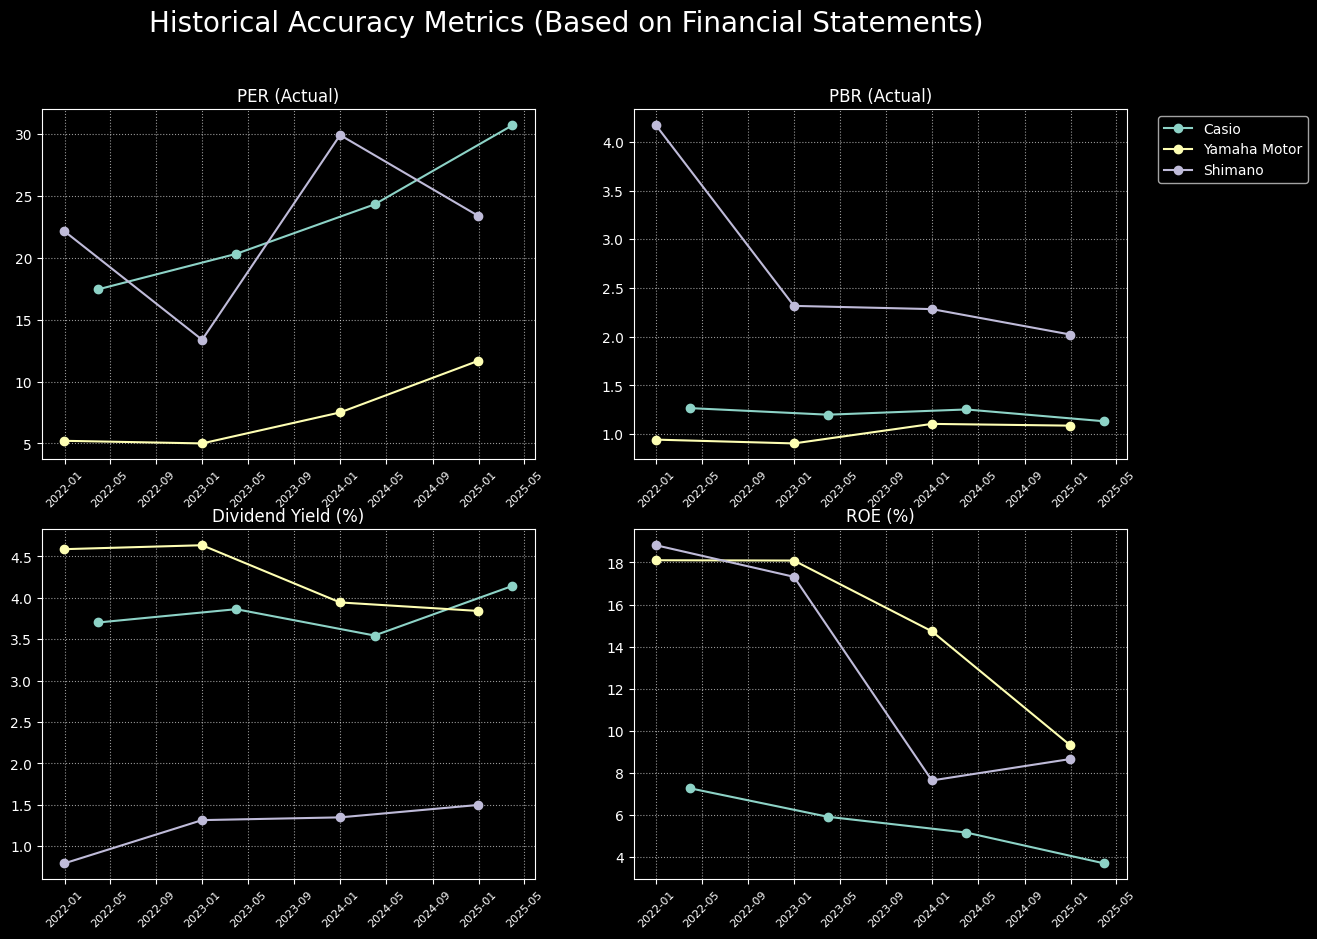

In [39]:
# 4つの指標を保持する辞書
results = {ticker: {'Date': [], 'PER': [], 'PBR': [], 'ROE': [], 'Div_Yield': []} for ticker in tickers}

for ticker in tickers:
    stock = yf.Ticker(ticker)

    fin = stock.financials
    bs = stock.balance_sheet
    divs = stock.actions['Dividends']

    if fin.empty or bs.empty:
        continue

    def get_row(df, keywords):
        for k in keywords:
            found = df.index[df.index.str.replace(' ', '').str.contains(k, case=False)]
            if not found.empty:
                return df.loc[found[0]]
        return pd.Series(dtype=float)

    net_income = get_row(fin, ['NetIncome', 'NetIncomeCommonStockholders'])
    equity = get_row(bs, ['StockholdersEquity', 'TotalEquity'])
    shares = stock.info.get('sharesOutstanding')

    for date in net_income.index:
        try:
            price_hist = stock.history(start=date - pd.Timedelta(days=7), end=date + pd.Timedelta(days=7))
            if price_hist.empty: continue
            price = price_hist['Close'].iloc[-1]

            if shares:
                eps = net_income[date] / shares
                bps = equity[date] / shares

                per = price / eps if eps > 0 else np.nan
                pbr = price / bps if bps > 0 else np.nan
                roe = (net_income[date] / equity[date]) * 100 if equity[date] > 0 else np.nan

                year_div = divs[divs.index.year == date.year].sum()
                div_yield = (year_div / price) * 100 if price > 0 else 0

                results[ticker]['Date'].append(date)
                results[ticker]['PER'].append(per)
                results[ticker]['PBR'].append(pbr)
                results[ticker]['ROE'].append(roe)
                results[ticker]['Div_Yield'].append(div_yield)
        except Exception:
            continue

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Historical Accuracy Metrics (Based on Financial Statements)', fontsize=20)

metrics_list = ['PER', 'PBR', 'Div_Yield', 'ROE']
titles = ['PER (Actual)', 'PBR (Actual)', 'Dividend Yield (%)', 'ROE (%)']

for i, metric in enumerate(metrics_list):
    ax = axes.flatten()[i]
    for ticker in tickers:
        df_plot = pd.DataFrame(results[ticker])
        if not df_plot.empty:
            df_plot = df_plot.sort_values('Date')
            ax.plot(df_plot['Date'], df_plot[metric], marker='o', label=stocks[ticker])

    ax.set_title(titles[i])
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.show()

- これくらいの可視化なら，日経会社情報とかYahoo!ファイナンスを直接見た方が早いな．価値ある分析って難しい．